Epoch 1/35


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.6689 - mae: 0.6275 - val_loss: 0.5440 - val_mae: 0.5390 - learning_rate: 0.0010
Epoch 2/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4967 - mae: 0.5355 - val_loss: 0.4591 - val_mae: 0.4860 - learning_rate: 0.0010
Epoch 3/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4363 - mae: 0.5013 - val_loss: 0.4047 - val_mae: 0.4606 - learning_rate: 0.0010
Epoch 4/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3673 - mae: 0.4554 - val_loss: 0.3270 - val_mae: 0.4119 - learning_rate: 0.0010
Epoch 5/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3026 - mae: 0.4182 - val_loss: 0.2482 - val_mae: 0.3553 - learning_rate: 0.0010
Epoch 6/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2558 - mae: 0.3790 - val_loss: 0.2311 - val_mae: 0.3529 - learning_rate: 0.0010
Epoch 7/35
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2240 - mae: 0.3539 - val_loss: 0.2191 - val_mae: 0.3613 - learning_rate: 0.0010
Epoch 8/35
27/27 ━━━━━━━

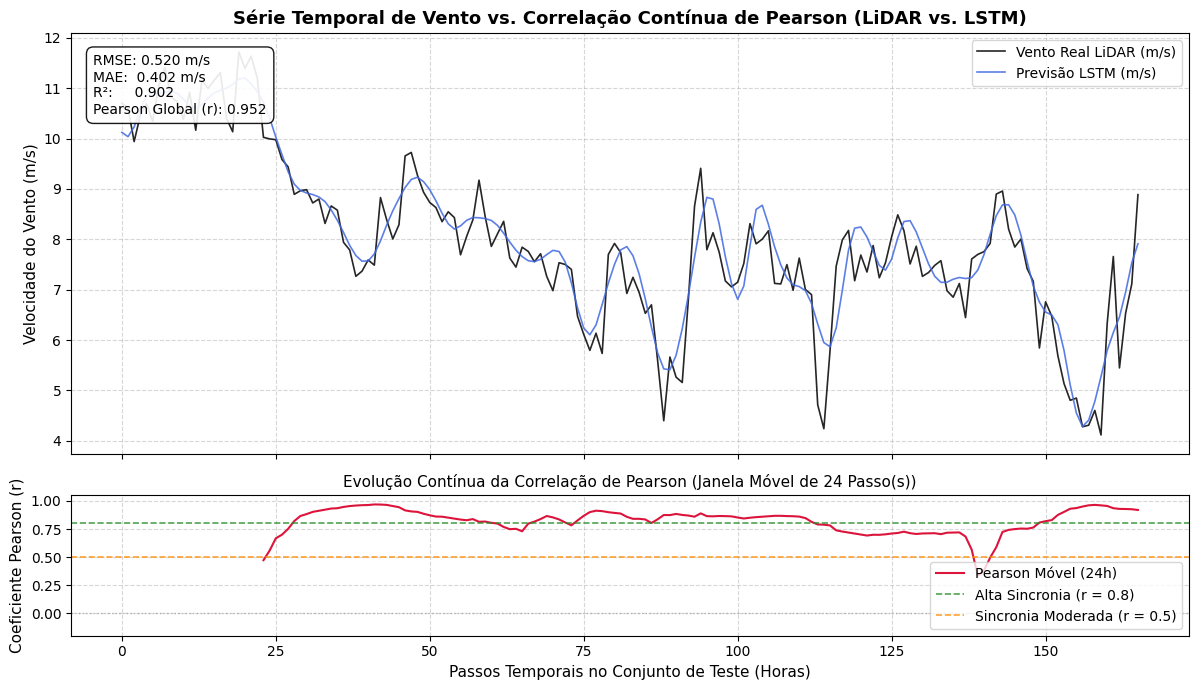

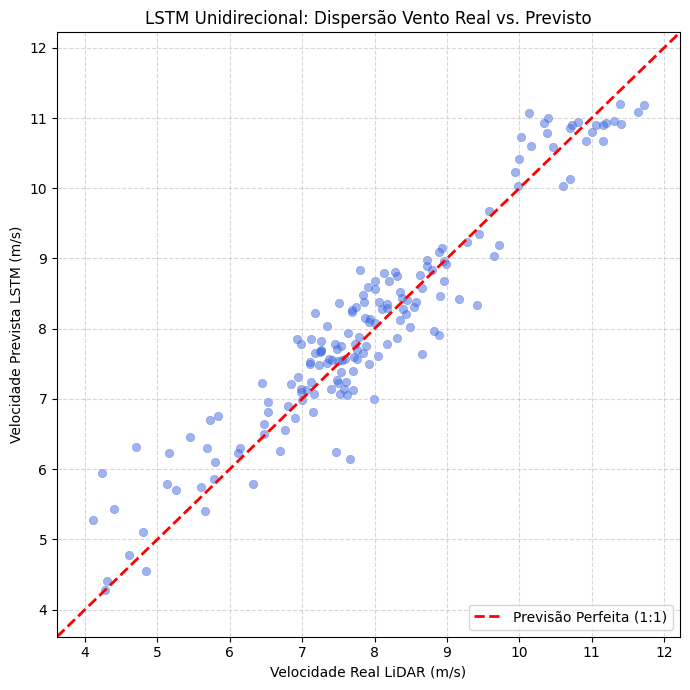

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# ==========================================
# 1. CARREGAMENTO E DIVISÃO TEMPORAL
# ==========================================
df = pd.read_parquet("data/approach_a.parquet")

features = ["ws100_era5", "ws100_lidar_clean"]
target = "ws100_lidar"

n = len(df)
train_df = df.iloc[: int(n * 0.7)]
val_df = df.iloc[int(n * 0.7) : int(n * 0.85)]
test_df = df.iloc[int(n * 0.85) :]

# ==========================================
# 2. NORMALIZAÇÃO SEPARADA (X e Y)
# ==========================================
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train_raw = scaler_x.fit_transform(train_df[features])
y_train_raw = scaler_y.fit_transform(train_df[[target]])

X_val_raw = scaler_x.transform(val_df[features])
y_val_raw = scaler_y.transform(val_df[[target]])

X_test_raw = scaler_x.transform(test_df[features])
y_test_raw = scaler_y.transform(test_df[[target]])

# ==========================================
# 3. JANELA DESLIZANTE (SLIDING WINDOW)
# ==========================================
def create_sequences(X_data, y_data, lookback=24):
  X_out, y_out = [], []
  for i in range(len(X_data) - lookback):
    X_out.append(X_data[i : i + lookback, :])
    y_out.append(y_data[i + lookback, 0])
  return np.array(X_out), np.array(y_out)

LOOKBACK = 24  # Usa as últimas 24h para prever a hora seguinte
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK)
X_val, y_val = create_sequences(X_val_raw, y_val_raw, LOOKBACK)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, LOOKBACK)

# ==========================================
# 4. MODELO LSTM UNIDIRECIONAL
# ==========================================
model = Sequential([
    LSTM(
        64, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1),
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Callbacks para otimização de treinamento
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# ==========================================
# 5. INFERÊNCIA E MÉTRICAS
# ==========================================
y_pred_scaled = model.predict(X_test)

y_real = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
pearson_global = np.corrcoef(y_real, y_pred)[0, 1]

print(f"--- Métricas Globais do Conjunto de Teste ---")
print(
    f"RMSE: {rmse:.3f} m/s | MAE: {mae:.3f} m/s | R²: {r2:.3f} | Pearson (r):"
    f" {pearson_global:.3f}\n"
)

# ==========================================
# 6. CÁLCULO DA CORRELAÇÃO DE PEARSON MÓVEL (ROLLING)
# ==========================================
# Converte para Pandas Series para aplicar a janela deslizante de correlação
s_real = pd.Series(y_real)
s_pred = pd.Series(y_pred)

# Define a janela de correlação (ex.: 24 passos = 24 horas na Abordagem A)
WINDOW_CORR = 24
rolling_pearson = s_real.rolling(window=WINDOW_CORR).corr(s_pred)

# ==========================================
# 7. VISUALIZAÇÃO CONTÍNUA DUAL-PANEL (SÉRIE + CORRELAÇÃO MÓVEL)
# ==========================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# --- PAINEL SUPERIOR: Série Temporal Real vs. Previsto ---
ax1.plot(
    y_real,
    label="Vento Real LiDAR (m/s)",
    color="black",
    linewidth=1.2,
    alpha=0.85,
)
ax1.plot(
    y_pred,
    label="Previsão LSTM (m/s)",
    color="royalblue",
    linewidth=1.2,
    alpha=0.85,
)
ax1.set_title(
    "Série Temporal de Vento vs. Correlação Contínua de Pearson (LiDAR vs."
    " LSTM)",
    fontsize=13,
    fontweight="bold",
)
ax1.set_ylabel("Velocidade do Vento (m/s)", fontsize=11)
ax1.legend(loc="upper right", frameon=True, facecolor="white")
ax1.grid(True, linestyle="--", alpha=0.5)

# --- PAINEL INFERIOR: Correlação de Pearson Móvel ---
ax2.plot(
    rolling_pearson,
    color="crimson",
    linewidth=1.5,
    label=f"Pearson Móvel ({WINDOW_CORR}h)",
)
ax2.axhline(
    y=0.8,
    color="forestgreen",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Alta Sincronia (r = 0.8)",
)
ax2.axhline(
    y=0.5,
    color="darkorange",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label="Sincronia Moderada (r = 0.5)",
)
ax2.axhline(y=0.0, color="gray", linestyle=":", linewidth=1.0, alpha=0.5)

ax2.set_title(
    f"Evolução Contínua da Correlação de Pearson (Janela Móvel de"
    f" {WINDOW_CORR} Passo(s))",
    fontsize=11,
)
ax2.set_xlabel("Passos Temporais no Conjunto de Teste (Horas)", fontsize=11)
ax2.set_ylabel("Coeficiente Pearson (r)", fontsize=11)
ax2.set_ylim(-0.2, 1.05)
ax2.legend(loc="lower right", frameon=True, facecolor="white")
ax2.grid(True, linestyle="--", alpha=0.5)

# Adiciona caixa informativa de métricas no gráfico superior
metrics_text = (
    f"RMSE: {rmse:.3f} m/s\nMAE:  {mae:.3f} m/s\nR²:     {r2:.3f}\nPearson Global"
    f" (r): {pearson_global:.3f}"
)
ax1.text(
    0.02,
    0.95,
    metrics_text,
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9),
)

plt.tight_layout()
plt.show()

# ==========================================
# 8. GRÁFICO DE DISPERSÃO (1:1 SCATTER PLOT)
# ==========================================
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=y_real, y=y_pred, alpha=0.5, color="royalblue", edgecolor=None
)

min_val = min(y_real.min(), y_pred.min()) - 0.5
max_val = max(y_real.max(), y_pred.max()) + 0.5
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Previsão Perfeita (1:1)",
)

plt.title(
    "LSTM Unidirecional: Dispersão Vento Real vs. Previsto", fontsize=12
)
plt.xlabel("Velocidade Real LiDAR (m/s)", fontsize=10)
plt.ylabel("Velocidade Prevista LSTM (m/s)", fontsize=10)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()